# Alternative Methods for Dating Abalone
Author: Matthew MacDonald SIN:100968453
## Introduction
Dating Abalone is a lengthy and tedious process consisting of cutting the Abalone's shell, staining it and counting the growth rings under amicroscope. The growth rings typically take 1 year to appear, and start developing after 1.5 years of life. Determining a better way to date Abalone could be beneficial to researchers as they would be able to do it in the field and idealy being able to do it without killing the animal.     

#### Description of Features
| Feature | Units | Description |
|-|-|-|
| Sex | N/A | Sex of the Abalone indicated by M for male, F for female, and I for infant
| Length | mm | from Longest distance across the shell |
| Diameter | mm | Measurement perpendicular to length |
| Height | mm | From surface to the top of the Abalone, with meat in the shell|
| Whole_Weight | g | Raw weight of Abalone |
| Shucked_Weight | g | Weight excluding shell |
| Gut_Weight | g | Weight of internal organs |
| Shell_Weight | g | Weight of shell alone |
| Rings | N/A | Amount of rings on the inside of the shell |
#### Considerations
1. Rows missing data for physical dimensions have been removed prior to analysis.
2. All continuous values have been scaled down by a factor of 200 by the original authors. 
#### Objective
Investigate the relationships between the age of the Abalone with other physical properties of it, ideally to determine a function for estimating age of the Abalone.




## Cleaning / Setup

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.display.max_columns = 100 # allows me to have scrollable tables used later

In [ ]:
# Load Data from CSV to dataframe 'Data'
data = pd.read_csv("abalone.csv")

Becuase the objective of this analysis is to determine an alternative way to date abalone without killing them, the features that require killing the Abalone to collect will not be considered for relationships. The only acception to this is the ring count because this is still neccesary for looking for age relationships.  

In [ ]:
data = data.drop('Shucked_Weight', axis=1)
data = data.drop('Gut_Weight', axis=1)
data = data.drop('Shell_Weight', axis=1)



All original continuous values were scaled down (factor of 200) by the authors of the data set, the scale function defined below is designed to bring them back to there original values. 

In [ ]:
def scale(value, scale = 200 ):
    return value * scale 

Applying the scale function to all continuous values in the dataframe

In [ ]:
data['Length'] = data["Length"].apply(scale)
data['Diameter'] = data["Diameter"].apply(scale)
data['Height'] = data["Height"].apply(scale)
data['Whole_Weight'] = data["Whole_Weight"].apply(scale)

## Analysis

In [ ]:
data.describe()

,Length,Diameter,Height,Whole_Weight,Rings
count,4175.000000,4175.000000,4175.000000,4175.00000,4175.000000
mean,104.812934,81.588024,27.916647,165.80091,9.935090
std,24.013856,19.843973,8.345082,98.06986,3.224227
min,15.000000,11.000000,2.000000,0.40000,1.000000
25%,90.000000,70.000000,23.000000,88.45000,8.000000
50%,109.000000,85.000000,28.000000,160.00000,9.000000
75%,123.000000,96.000000,33.000000,230.70000,11.000000
max,163.000000,130.000000,226.000000,565.10000,29.000000


From first look, all values are reasonable measurements, though there is some noticeably large varience between the mean and min/max values of the data. The data will now be further seperated by abalone gender to see if there are any noticeable differences. 

In [ ]:
sex_sep = data.groupby("Sex")
sex_sep.describe()


Length                                                          Diameter  \
      count        mean        std   min    25%    50%    75%    max    count   
Sex                                                                             
F    1307.0  115.818669  17.231911  55.0  105.0  118.0  128.0  163.0   1307.0   
I    1340.0   85.565672  21.779073  15.0   72.0   87.0  102.0  145.0   1340.0   
M    1528.0  112.278141  20.539463  31.0  101.0  116.0  126.0  156.0   1528.0   

                                                            Height             \
          mean        std   min   25%   50%     75%    max   count       mean   
Sex                                                                             
F    90.946442  14.190841  39.0  82.0  93.0  101.00  130.0  1307.0  31.602142   
I    65.311194  17.626895  11.0  54.0  67.0   78.25  110.0  1340.0  21.631343   
M    87.857330  16.879613  22.0  79.0  91.0  100.00  126.0  1528.0  30.276178   

                                             Whole_Weight              \
          std  min    25%   50%   75%    max        count        mean   
Sex                                                                     
F    7.996798  3.0  28.00  32.0  35.0  226.0       1307.0  209.306427   
I    6.349062  2.0  17.75  22.0  26.0   44.0       1340.0   86.317388   
M    6.960900  5.0  26.00  31.0  35.0  103.0       1528.0  198.291885   

                                                        Rings             \
           std   min      25%     50%      75%    max   count       mean   
Sex                                                                        
F    86.063263  16.0  146.000  207.70  264.050  531.4  1307.0  11.129304   
I    57.274600   0.4   41.100   76.80  119.950  409.9  1340.0   7.891791   
M    94.116275   3.1  134.325  195.15  253.125  565.1  1528.0  10.705497   

                                           
          std  min  25%   50%   75%   max  
Sex                                        
F    3.104256  5.0  9.0  10.0  12.0  29.0  
I    2.512896  1.0  6.0   8.0   9.0  21.0  
M    3.026349  3.0  9.0  10.0  12.0  27.0

Male and Female Abalone seem to have similar qualitys whereas the data on infant Abalone is much more spread out. The infant data will now be seperated from the adult Abalone and be analysed seperatly.

Firstly, the adults only: 

In [ ]:
adult_data = data.drop(data[data.Sex == "I"].index) # This creates a new dataframe with the Infant values removed.  
adult_data.name = "Adult Data"
adult_data.describe()


,Length,Diameter,Height,Whole_Weight,Rings
count,2835.000000,2835.000000,2835.000000,2835.000000,2835.000000
mean,113.910406,89.281481,30.887478,203.369841,10.900882
std,19.164143,15.770041,7.484284,90.643484,3.069252
min,31.000000,22.000000,3.000000,3.100000,3.000000
25%,103.000000,80.000000,27.000000,140.250000,9.000000
50%,117.000000,92.000000,31.000000,200.600000,10.000000
75%,127.000000,100.000000,35.000000,257.900000,12.000000
max,163.000000,130.000000,226.000000,565.100000,29.000000


Already a noticeable decrease in standard deviation across all ranges in the data. 

The function defined below is designed to make it easier to create regression plots. 

In [ ]:
def drawGraph(xData, yData, dataSet, plotFunc = sns.regplot): 
    p = plotFunc(x=xData, y = yData, data = dataSet)
    p.set(title = xData + ' VS ' + yData + ' From Table: ' + dataSet.name)
    plt.show(p)

Below, are the regression plots relating the Ring count and other statistics for the adult only set of Abalone. 

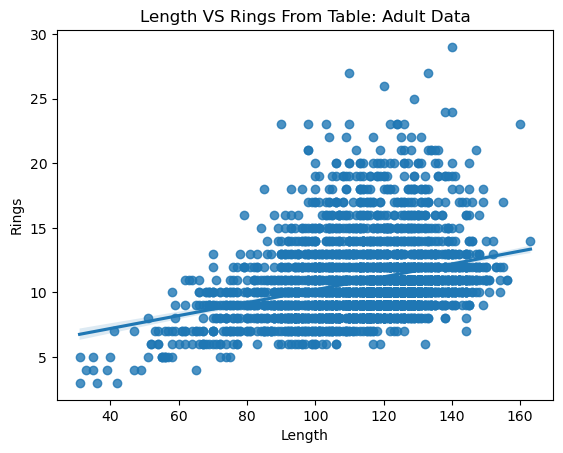

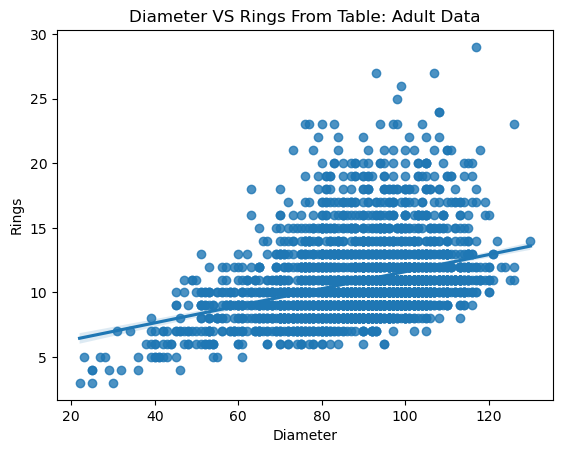

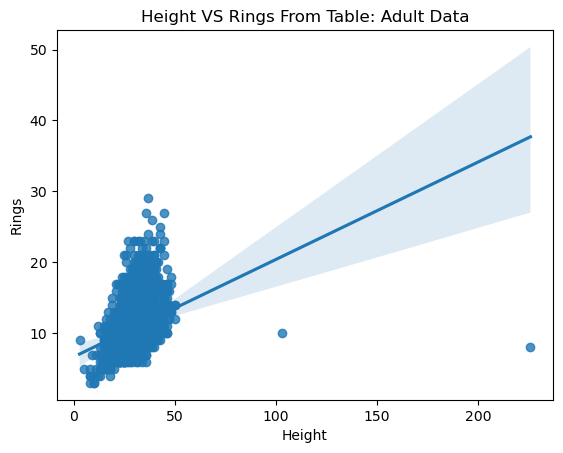

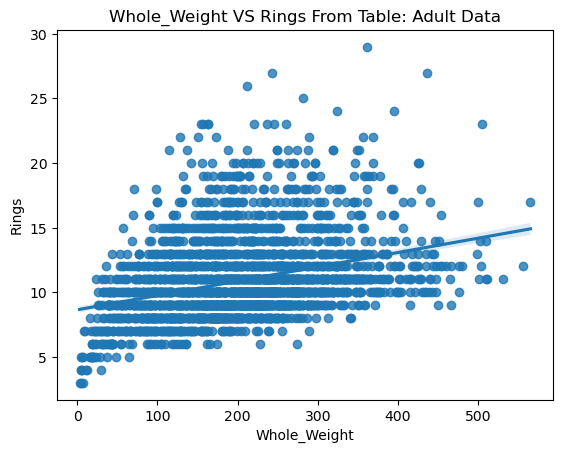

In [36]:
drawGraph("Length", "Rings", adult_data)
drawGraph("Diameter", "Rings", adult_data)
drawGraph("Height", "Rings", adult_data)
drawGraph("Whole_Weight", "Rings", adult_data)


These graphs seem to show very little correlation between any of the values regressed on, a numerical look at the relationships may be more informational. The funtion below generates a table of the pearson correlation coeficient (r value) from a linear regression between all categories across the dataframe.  

In [37]:
adult_data.corr(method= 'pearson', numeric_only=True)

,Length,Diameter,Height,Whole_Weight,Rings
Length,1.000000,0.978017,0.700392,0.921738,0.311761
Diameter,0.978017,1.000000,0.708706,0.917171,0.339400
Height,0.700392,0.708706,1.000000,0.716792,0.334905
Whole_Weight,0.921738,0.917171,0.716792,1.000000,0.327539
Rings,0.311761,0.339400,0.334905,0.327539,1.000000


This table confirms that there is no real relationship between any of the values with the amount of rings on the shell, specifically for the adult Abalone. Now for the infants, the code below creates a dataframe with only infant Abalone data.  

In [15]:
infant_data = data.drop(data[data.Sex == "M"].index)
infant_data = infant_data.drop(data[data.Sex == "F"].index)
infant_data.name = "Infant Data"

Below, are the regression plots relating the Ring count and other statistics for the infant set of Abalone. 

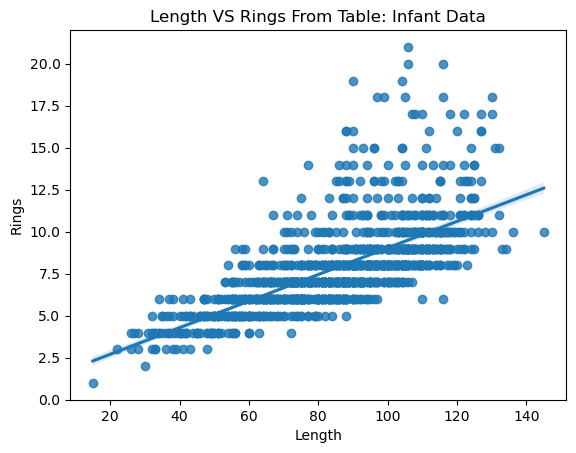

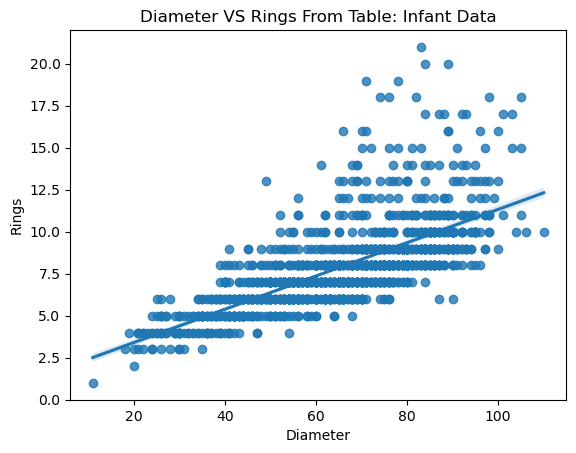

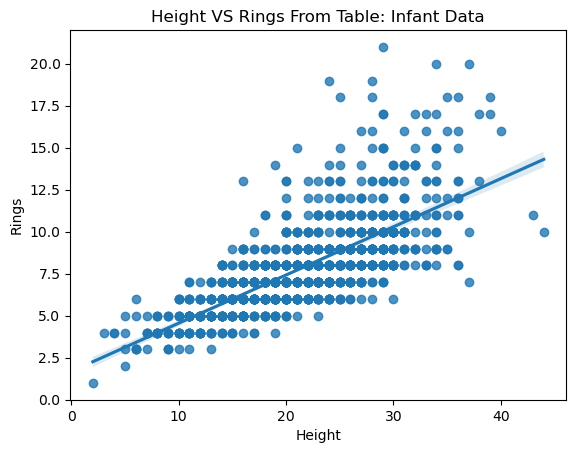

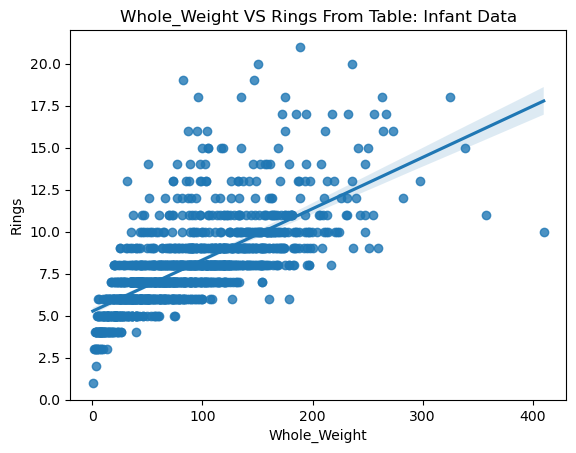

In [39]:
drawGraph("Length", "Rings", infant_data)
drawGraph("Diameter", "Rings", infant_data)
drawGraph("Height", "Rings", infant_data)
drawGraph("Whole_Weight", "Rings", infant_data)

These graphs seem to show more correlation between values than the adult set. Again a numerical look may be more insightful.  

In [16]:
infant_data.corr(method= 'pearson', numeric_only=True)

,Length,Diameter,Height,Whole_Weight,Rings
Length,1.000000,0.986109,0.914141,0.920936,0.685835
Diameter,0.986109,1.000000,0.919151,0.923644,0.694922
Height,0.914141,0.919151,1.000000,0.897052,0.724592
Whole_Weight,0.920936,0.923644,0.897052,1.000000,0.696172
Rings,0.685835,0.694922,0.724592,0.696172,1.000000


As shown in the graphs, there are much stronger correlations in this dataset, the strongest of which being the Height and the Rings. Using this data a function to approximate the age of an infant Abalone can be derived using the numpy polyfit function to get regression values. Note that the function follow the form of y = mx + c where y is the number of rings, m is the slope (Rings/mm), x is the height of the Abalone(mm), and c is the vertical translation of the function.  

In [17]:
x = data['Height'].to_numpy()
y = data['Rings'].to_numpy()
m, c = np.polyfit(x, y, 1)
print(f"Slope (m): {m:.3f}")
print(f"Intercept (c): {c:.3f}")

Slope (m): 0.215
Intercept (c): 3.921


Above are the values m and c used to give the function: Rings = 0.215 * Height + 3.921 for estimating the amount of rings on an Infant Abalone's shell.

## Discussion
In this assignment, I explored the type relationships between the phyiscal properties of Abalone such as Height, Length, Diameter, and weight, and amount of rings on the Abalones shell to aproximate its age without the need to kill it. When investigating it was found that Adult and Infant Abalone are physicaly different and would require being seperated to analyze further. After the data was seperated it was found that the adult Abalone varried in size and weight to far to be directly correlated to the ring count on the shell, however for infants, there was a trend. When analysed with a linear regression there proved to be a moderate positive correlation between the amount of rings, and the height of the Abalone. using numpy, the slope and vertical shift for the linear approximation were found being 0.215, and 3.921 respectivly. It should be noted that this function only approximates the amount of rings of the Abalone, and not the age directly. To find relationships in the adult set, more complex regressions may want to be explored.

## References
1. Source data - https://archive-beta.ics.uci.edu/dataset/1/abalone
2. Pandas for data manipulation
3. Seaborn for data visualization
4. Matplotlib for data visualization